# AICE Associate 대비 실습 과정 — 4회차 예제 2
## 타이타닉 데이터 전처리 (수치형 + 범주형, 분류)

> **선수 학습**: `04_데이터전처리하기.ipynb`, `04-1_전처리예제_캘리포니아주택.ipynb`  
> **데이터**: `data/titanic_train.csv` (891명)  
> **목표 변수**: `생존` (1 = 생존, 0 = 사망) → **분류** 문제

### 04-1 과 무엇이 다른가

| 항목 | 04-1 캘리포니아 주택 | 04-2 타이타닉 |
|------|------|------|
| 컬럼 | 수치형만 | **수치형 + 범주형 + 텍스트(이름, 티켓)** |
| 원래 결측 | 없음 | 나이 20%, 객실번호 77%, 탑승항구 2명 |
| 핵심 기술 | 관계 기반 대체, clip, 로그 변환 | **텍스트에서 파생 변수 추출**, 범주형 결측 대체, **결측 자체를 정보로 활용** |
| 분할 | 소득 구간으로 층화 | 목표 변수(생존)로 층화 |

### 이 예제의 흐름

```
① 불러오기 → ② 전처리를 위한 EDA → ③ 결측치 랜덤 생성 (수치형 + 범주형)
→ ④ 텍스트 파생(호칭) → ⑤ 결측 처리 (방법별 정확도 비교) → ⑥ 불필요 컬럼 정리
→ ⑦ 이상치·변환 → ⑧ 구간화 → ⑨ 인코딩 → ⑩ 분할·스케일링 → ⑪ 전처리 전후 비교 → ⑫ 저장 → 실습 문제
```

---
## 0. 환경 준비, 데이터 불러오기

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", 30)
pd.set_option("display.width", 120)

DATA_DIR = "data"

In [2]:
# 한글 폰트 설정 (1회차와 동일). Colab 은 나눔폰트 설치 후 런타임 재시작 필요.
#   !apt-get -qq install fonts-nanum
#   !rm -rf ~/.cache/matplotlib
from matplotlib import font_manager


def set_korean_font() -> str:
  candidates = ["AppleGothic", "Malgun Gothic", "NanumGothic", "NanumBarunGothic"]
  installed = {f.name for f in font_manager.fontManager.ttflist}
  for name in candidates:
    if name in installed:
      plt.rcParams["font.family"] = name
      plt.rcParams["axes.unicode_minus"] = False
      return name
  plt.rcParams["axes.unicode_minus"] = False
  return "(한글 폰트 없음 - 그래프의 한글이 깨질 수 있음)"


print("적용된 폰트:", set_korean_font())

sns.set_theme(style="whitegrid", font=plt.rcParams["font.family"][0], rc={"axes.unicode_minus": False})

적용된 폰트: AppleGothic


In [3]:
TITANIC_COLS = {
  "PassengerId": "승객ID",
  "Survived": "생존",                  # 1 = 생존, 0 = 사망 <- 목표 변수
  "Pclass": "객실등급",                # 1등석 / 2등석 / 3등석 (숫자지만 순서 있는 범주)
  "Name": "이름",                      # "성, 호칭. 이름" 형식 (예: Braund, Mr. Owen Harris)
  "Sex": "성별",                       # male / female
  "Age": "나이",
  "SibSp": "동반형제배우자",           # 함께 탄 형제·배우자 수
  "Parch": "동반부모자녀",             # 함께 탄 부모·자녀 수
  "Ticket": "티켓번호",
  "Fare": "운임",                      # 지불한 요금 (파운드)
  "Cabin": "객실번호",                 # 예: C85 (앞 글자가 갑판 층)
  "Embarked": "탑승항구",              # C = Cherbourg, Q = Queenstown, S = Southampton
}

if not os.path.exists(f"{DATA_DIR}/titanic_train.csv"):
  raise FileNotFoundError(f"{DATA_DIR}/titanic_train.csv 가 없습니다. data 폴더에 실습 파일을 넣어 주세요.")

titanic = pd.read_csv(f"{DATA_DIR}/titanic_train.csv").rename(columns=TITANIC_COLS)
print(titanic.shape)
titanic.head()

(891, 12)


,승객ID,생존,객실등급,이름,성별,나이,동반형제배우자,동반부모자녀,티켓번호,운임,객실번호,탑승항구
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


---
## 1. 전처리를 위한 탐색적 데이터 분석 (EDA)

| 질문 | 확인 방법 | 찾으면 하는 전처리 |
|------|------|------|
| ① 타입·결측은? | `info()`, 결측 비율 | 대체 / 컬럼 삭제 / 결측 여부를 변수로 |
| ② 목표 변수는 균형인가? | `value_counts(normalize=True)` | 층화 분할, 평가지표 선택 |
| ③ 범주형은 생존과 관련 있나? | 범주별 생존율 | 인코딩 방식, 변수 선택 |
| ④ 수치형 분포는? | 히스토그램, 박스플롯, `skew()` | 로그 변환, 구간화 |
| ⑤ 텍스트에 숨은 정보는? | 문자열 패턴 | 파생 변수 추출 |
| ⑥ 고유값이 너무 많은 컬럼은? | `nunique()` | 삭제 또는 요약 |

### 1.1 타입과 결측

In [4]:
titanic.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   승객ID     891 non-null    int64  
 1   생존       891 non-null    int64  
 2   객실등급     891 non-null    int64  
 3   이름       891 non-null    object 
 4   성별       891 non-null    object 
 5   나이       714 non-null    float64
 6   동반형제배우자  891 non-null    int64  
 7   동반부모자녀   891 non-null    int64  
 8   티켓번호     891 non-null    object 
 9   운임       891 non-null    float64
 10  객실번호     204 non-null    object 
 11  탑승항구     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [5]:
missing = pd.DataFrame({"결측수": titanic.isnull().sum(), "결측비율(%)": (titanic.isnull().mean() * 100).round(1)})
missing[missing["결측수"] > 0].sort_values("결측수", ascending=False)

,결측수,결측비율(%)
객실번호,687,77.1
나이,177,19.9
탑승항구,2,0.2


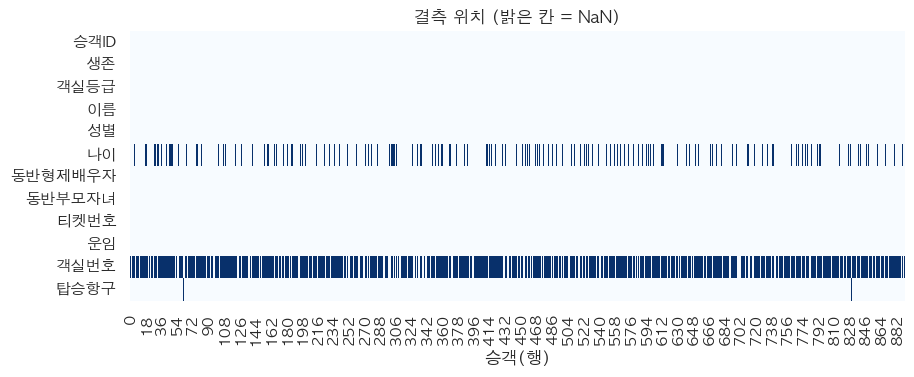

In [6]:
fig, ax = plt.subplots(figsize=(10, 3.5))
sns.heatmap(titanic.isnull().T, cbar=False, cmap="Blues", ax=ax)
ax.set_title("결측 위치 (밝은 칸 = NaN)")
ax.set_xlabel("승객(행)")
plt.show()

- `객실번호` 는 77% 가 비어 있어 **값으로 채우는 것이 무의미** 합니다. 대신 "객실 정보가 있었는가" 자체가 정보일 수 있습니다. (1.7)
- `나이` 20% 결측은 대체 대상입니다. 무엇으로 채울지는 1.5 에서 정합니다.

### 1.2 목표 변수 균형

In [7]:
print(titanic["생존"].value_counts())
print(titanic["생존"].value_counts(normalize=True).round(3))

생존
0    549
1    342
Name: count, dtype: int64
생존
0    0.616
1    0.384
Name: proportion, dtype: float64


생존 약 38% : 사망 약 62%. 심한 불균형은 아니지만 **분할할 때 `stratify=y`** 로 비율을 유지합니다.

### 1.3 범주형 변수와 생존율

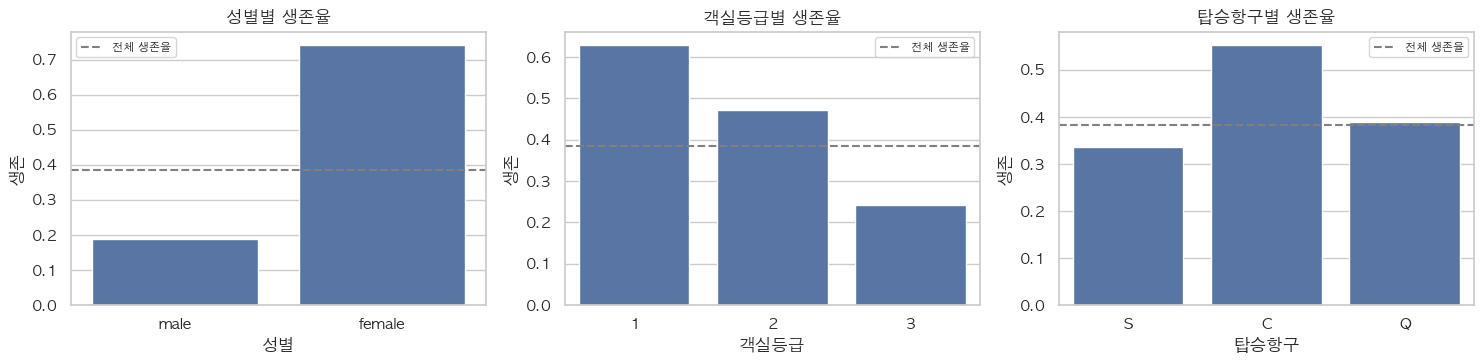

성별 {'female': 0.742, 'male': 0.189}
객실등급 {1: 0.63, 2: 0.473, 3: 0.242}
탑승항구 {'C': 0.554, 'Q': 0.39, 'S': 0.337}


In [8]:
fig, axes = plt.subplots(1, 3, figsize=(15, 3.8))
for ax, col in zip(axes, ["성별", "객실등급", "탑승항구"]):
  sns.barplot(data=titanic, x=col, y="생존", errorbar=None, ax=ax)
  ax.axhline(titanic["생존"].mean(), color="gray", linestyle="--", label="전체 생존율")
  ax.set_title(f"{col}별 생존율")
  ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

for col in ["성별", "객실등급", "탑승항구"]:
  print(col, titanic.groupby(col)["생존"].mean().round(3).to_dict())

- **성별** 이 가장 강력합니다. 여성 생존율이 남성의 약 4배입니다. → 이진 인코딩 `map`
- **객실등급** 은 1 → 3 등석으로 갈수록 생존율이 낮아지는 **순서** 가 있습니다. → 숫자 그대로(순서형) 사용
- **탑승항구** 는 순서가 없는 범주입니다. → 원-핫 인코딩

### 1.4 수치형 변수: 나이와 운임

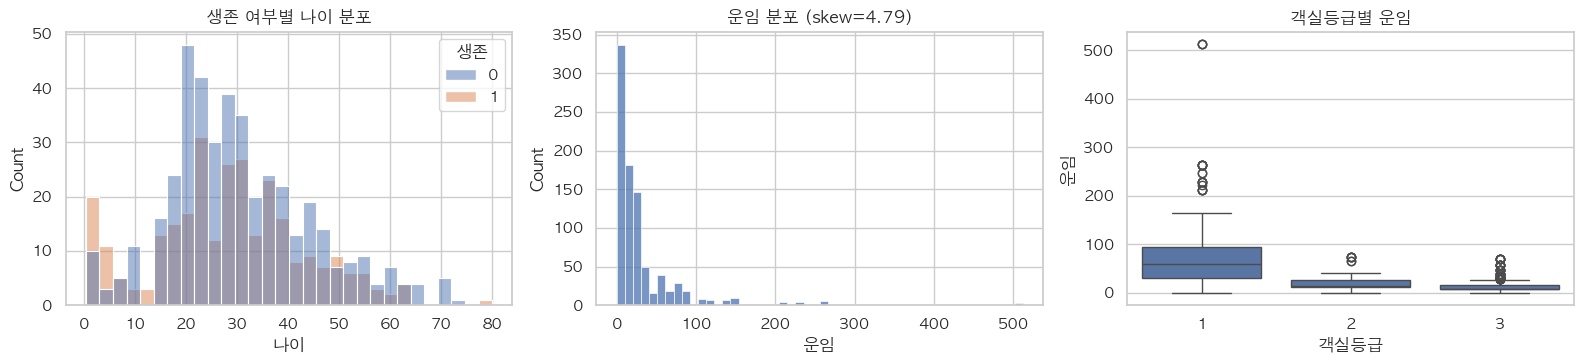

운임 최댓값: 512.3292 | 운임 0 인 승객: 15
객실등급별 운임 중앙값: {1: 60.3, 2: 14.2, 3: 8.0}


In [9]:
fig, axes = plt.subplots(1, 3, figsize=(16, 3.8))
sns.histplot(data=titanic, x="나이", hue="생존", bins=30, multiple="layer", alpha=0.5, ax=axes[0])
axes[0].set_title("생존 여부별 나이 분포")

sns.histplot(titanic["운임"], bins=50, ax=axes[1])
axes[1].set_title(f"운임 분포 (skew={titanic['운임'].skew():.2f})")

sns.boxplot(data=titanic, x="객실등급", y="운임", ax=axes[2])
axes[2].set_title("객실등급별 운임")
plt.tight_layout()
plt.show()

print("운임 최댓값:", titanic["운임"].max(), "| 운임 0 인 승객:", (titanic["운임"] == 0).sum())
print("객실등급별 운임 중앙값:", titanic.groupby("객실등급")["운임"].median().round(1).to_dict())

- **나이**: 0~10세 구간에서 생존(주황)이 사망보다 많습니다. "아이 먼저" 가 데이터에 보입니다. → 나이를 **구간화** 하면 이 효과가 잘 드러납니다.
- **운임**: 왜도가 매우 크고 500 이 넘는 극단값이 있습니다. 하지만 실제로 비싼 1등석 표라 **틀린 값이 아닙니다.** → 삭제 대신 **로그 변환**
- **운임은 객실등급에 따라 크게 다릅니다.** → 운임 결측은 **객실등급별 중앙값** 으로 채우는 것이 자연스럽습니다.

### 1.5 텍스트 속 정보: 이름에서 호칭 꺼내기

이름은 `"성, 호칭. 이름"` 형식입니다. **호칭(Mr, Mrs, Miss, Master…)** 은 성별과 나이대를 동시에 알려 줍니다. Master 는 **남자 아이** 를 부르는 호칭입니다.

In [10]:
title = titanic["이름"].str.extract(r",\s*([^\.]+)\.", expand=False)    # 쉼표 뒤 ~ 마침표 앞
print(title.value_counts())

이름
Mr              517
Miss            182
Mrs             125
Master           40
Dr                7
Rev               6
Mlle              2
Major             2
Col               2
the Countess      1
Capt              1
Ms                1
Sir               1
Lady              1
Mme               1
Don               1
Jonkheer          1
Name: count, dtype: int64


In [11]:
title_view = pd.DataFrame({"호칭": title, "나이": titanic["나이"], "생존": titanic["생존"]})
summary = title_view.groupby("호칭").agg(인원=("생존", "size"), 나이중앙값=("나이", "median"),
                                         나이결측=("나이", lambda s: s.isna().sum()), 생존율=("생존", "mean"))
summary.sort_values("인원", ascending=False).head(6).round(2)

,인원,나이중앙값,나이결측,생존율
호칭,,,,
Mr,517,30.0,119,0.16
Miss,182,21.0,36,0.70
Mrs,125,35.0,17,0.79
Master,40,3.5,4,0.57
Dr,7,46.5,1,0.43
Rev,6,46.5,0,0.00


- 호칭별로 **나이 중앙값이 크게 다릅니다** (Master 약 3.5세, Mr 30세, Mrs 35세). → 나이 결측을 전체 중앙값(28세) 하나로 채우면 Master 아이도 28세가 됩니다. **호칭별 중앙값** 이 훨씬 정확할 것입니다. (4장에서 채점)
- 호칭이 성별을 알려 주므로 **성별이 비어 있으면 호칭으로 추론** 할 수 있습니다.
- 인원이 적은 호칭(Dr, Rev, Col…)은 **"기타" 로 묶어야** 원-핫 컬럼이 폭발하지 않습니다.

### 1.6 가족 정보

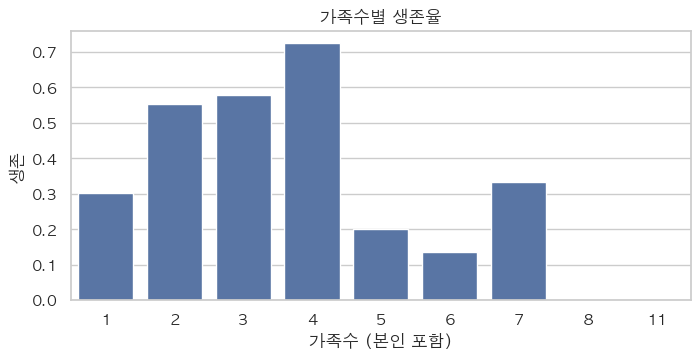

row_0    1    2    3   4   5   6   7  8  11  All
생존                                              
0      374   72   43   8  12  19   8  6   7  549
1      163   89   59  21   3   3   4  0   0  342
All    537  161  102  29  15  22  12  6   7  891


In [12]:
family = titanic["동반형제배우자"] + titanic["동반부모자녀"] + 1
fig, ax = plt.subplots(figsize=(8, 3.5))
sns.barplot(x=family, y=titanic["생존"], errorbar=None, ax=ax)
ax.set_xlabel("가족수 (본인 포함)")
ax.set_title("가족수별 생존율")
plt.show()
print(pd.crosstab(family, titanic["생존"], margins=True).T)

혼자(1명)는 생존율이 낮고 2~4명은 높으며 5명 이상은 다시 낮습니다. **직선 관계가 아니므로** 가족수를 그대로 쓰기보다 **혼자 / 소가족 / 대가족** 으로 구간화하면 선형 모델이 이 패턴을 잡기 쉽습니다.

### 1.7 고유값이 많은 컬럼과 "결측 자체의 의미"

In [13]:
print(titanic[["이름", "티켓번호", "객실번호", "승객ID"]].nunique())

이름      891
티켓번호    681
객실번호    147
승객ID    891
dtype: int64


In [14]:
has_cabin = titanic["객실번호"].notna().astype(int)
print("객실정보 있음/없음 별 생존율:", titanic.groupby(has_cabin)["생존"].mean().round(3).to_dict())
print("객실정보 있음 비율(객실등급별):", has_cabin.groupby(titanic["객실등급"]).mean().round(2).to_dict())

객실정보 있음/없음 별 생존율: {0: 0.3, 1: 0.667}
객실정보 있음 비율(객실등급별): {1: 0.81, 2: 0.09, 3: 0.02}


- `이름`, `승객ID` 는 사람마다 다르고, `티켓번호` 도 고유값이 수백 개입니다. 그대로는 모델이 배울 패턴이 없습니다. → **삭제** (이름은 호칭만 뽑고 삭제)
- 객실번호가 **기록된 승객의 생존율이 훨씬 높습니다.** 기록이 주로 1등석 승객에게 남아 있기 때문입니다. → `객실정보유무` (0/1) 파생 후 `객실번호` 삭제. **"비어 있다" 는 사실 자체가 정보** 가 되는 예입니다.

### 1.8 EDA 결론: 전처리 계획표

| 컬럼 | 발견 | 전처리 |
|------|------|------|
| 이름 | 호칭에 성별·나이대 정보 | `호칭` 추출 → 드문 호칭은 "기타" → 원-핫, 이름 삭제 |
| 나이 | 결측 20%, 호칭별 차이 큼, 어린이 생존율 높음 | 호칭별 중앙값 대체, `나이구간` 구간화 |
| 운임 | 왜도 4.8, 객실등급과 강한 관계 | 객실등급별 중앙값 대체, `log1p` |
| 성별 | 가장 강한 변수 | 결측은 호칭으로 추론, `map` 0/1 |
| 탑승항구 | 순서 없는 범주, 결측 소수 | 최빈값 대체, 원-핫 |
| 객실등급 | 순서 있는 범주 | 숫자 그대로 |
| 동반형제배우자, 동반부모자녀 | 가족수와 생존이 비선형 | `가족수` → `가족규모` 구간화 |
| 객실번호 | 77% 결측, 기록 여부가 생존과 관련 | `객실정보유무` 파생 후 삭제 |
| 승객ID, 티켓번호 | 고유값 과다 | 삭제 |
| 생존 | 38 : 62 | 층화 분할 |

---
## 2. 실습용 데이터셋 만들기: 결측치 랜덤 생성 (수치형 + 범주형)

원래 결측에 더해, **전처리 직전** 에 수치형 2개·범주형 2개 컬럼에 결측을 추가로 만듭니다. **원래 값이 있던 칸만** 골라 지우므로, 지운 칸은 정답을 알고 있어 대체 결과를 채점할 수 있습니다.

| 구분 | 컬럼 | 추가 결측 비율 | 의도 |
|------|------|:---:|------|
| 수치형 | `나이` | 5% | 원래 결측 20% 에 추가. 그룹별 대체 실습 |
| 수치형 | `운임` | 5% | 객실등급과의 관계 활용 |
| 범주형 | `성별` | 3% | 호칭으로 추론하는 **도메인 기반 대체** |
| 범주형 | `탑승항구` | 3% | 최빈값 대체 |

In [15]:
def make_missing(df: pd.DataFrame, ratios: dict[str, float], seed: int = 42) -> tuple[pd.DataFrame, dict[str, pd.Index]]:
  '''원래 값이 있는 칸 중에서 컬럼별 비율만큼 무작위로 골라 NaN 으로 바꾼다.
  반환: (결측이 추가된 복사본, {컬럼: 인위적으로 지운 행 인덱스})'''
  rng = np.random.default_rng(seed)
  out = df.copy()
  masked = {}
  for col, ratio in ratios.items():
    candidates = out.index[out[col].notna()]               # 이미 비어 있는 칸은 제외
    n_missing = int(len(out) * ratio)
    rows = rng.choice(candidates, size=n_missing, replace=False)
    out.loc[rows, col] = np.nan
    masked[col] = pd.Index(rows)
  return out, masked


MISSING_RATIOS = {"나이": 0.05, "운임": 0.05, "성별": 0.03, "탑승항구": 0.03}

titanic_true = titanic.copy()                              # 정답 보관용
titanic, MASKED = make_missing(titanic, MISSING_RATIOS, seed=42)

pd.DataFrame({
  "원래 결측": titanic_true.isnull().sum(),
  "추가 결측": pd.Series({c: len(idx) for c, idx in MASKED.items()}),
  "현재 결측": titanic.isnull().sum(),
}).fillna(0).astype(int).query("`현재 결측` > 0")

,원래 결측,추가 결측,현재 결측
객실번호,687,0,687
나이,177,44,221
성별,0,26,26
운임,0,44,44
탑승항구,2,26,28


In [16]:
print("현재 dtype:", titanic[["나이", "운임", "성별", "탑승항구"]].dtypes.to_dict())
print("결측이 하나라도 있는 승객:", titanic.isnull().any(axis=1).sum(), "/", len(titanic))
print("객실번호를 빼고 봐도:", titanic.drop(columns=["객실번호"]).isnull().any(axis=1).sum(), "명 -> dropna 하면 이만큼 사라진다")

현재 dtype: {'나이': dtype('float64'), '운임': dtype('float64'), '성별': dtype('O'), '탑승항구': dtype('O')}
결측이 하나라도 있는 승객: 742 / 891
객실번호를 빼고 봐도: 289 명 -> dropna 하면 이만큼 사라진다


---
## 3. 텍스트에서 파생 변수 만들기: 호칭

결측 대체에 호칭을 쓰려면 **먼저** 만들어야 합니다. 이름은 결측이 없으므로 모든 승객의 호칭을 구할 수 있습니다.

In [17]:
TITLE_MAP = {"Mlle": "Miss", "Ms": "Miss", "Mme": "Mrs"}     # 프랑스식·약식 호칭을 같은 뜻으로 통일
MAIN_TITLES = ["Mr", "Mrs", "Miss", "Master"]


def extract_title(names: pd.Series) -> pd.Series:
  t = names.str.extract(r",\s*([^\.]+)\.", expand=False).str.strip()
  t = t.replace(TITLE_MAP)
  return t.where(t.isin(MAIN_TITLES), "기타")             # 주요 4개가 아니면 "기타"


titanic["호칭"] = extract_title(titanic["이름"])
titanic["호칭"].value_counts()

호칭
Mr        517
Miss      185
Mrs       126
Master     40
기타         23
Name: count, dtype: int64

---
## 4. 결측치 처리: 방법별 정확도 비교

**인위적으로 지운 칸만** 골라 정답과 비교합니다. 수치형은 MAE(평균 절대 오차, 작을수록 좋음), 범주형은 정확도(높을수록 좋음)로 채점합니다.

### 4.1 수치형: 나이

In [18]:
def score_numeric(filled: pd.Series, col: str) -> float:
  idx = MASKED[col]
  return round(float((filled[idx] - titanic_true.loc[idx, col]).abs().mean()), 2)


age = titanic["나이"]
age_candidates = {
  "평균": age.fillna(age.mean()),
  "중앙값": age.fillna(age.median()),
  "객실등급별 중앙값": age.fillna(age.groupby(titanic["객실등급"]).transform("median")),
  "호칭별 중앙값": age.fillna(age.groupby(titanic["호칭"]).transform("median")),
  "객실등급+호칭별 중앙값": age.fillna(age.groupby([titanic["객실등급"], titanic["호칭"]]).transform("median")),
}
pd.Series({m: score_numeric(f, "나이") for m, f in age_candidates.items()}, name="나이 MAE(세)").sort_values()

객실등급+호칭별 중앙값    7.11
호칭별 중앙값         7.86
객실등급별 중앙값       8.45
중앙값             9.59
평균              9.95
Name: 나이 MAE(세), dtype: float64

호칭을 쓰면 전체 중앙값보다 오차가 크게 줄어듭니다. EDA 1.5 의 예상이 맞았습니다. 그룹을 두 개(객실등급 + 호칭)로 쪼개면 조금 더 좋아지지만, 그룹이 잘게 나뉠수록 **그룹 안에 값이 하나도 없어** 중앙값을 못 구하는 칸이 생길 수 있습니다. 그래서 실무에서는 **세밀한 그룹 → 큰 그룹 → 전체** 순서로 단계적으로 채웁니다.

In [19]:
def fill_age(df: pd.DataFrame, ref: pd.DataFrame) -> pd.Series:
  '''나이 대체: 객실등급+호칭 → 호칭 → 전체 중앙값 순서. 통계는 ref(학습 데이터) 기준.'''
  by_two = ref.groupby(["객실등급", "호칭"])["나이"].median()
  by_title = ref.groupby("호칭")["나이"].median()
  filled = df["나이"].copy()
  key_two = pd.MultiIndex.from_arrays([df["객실등급"], df["호칭"]])
  filled = filled.fillna(pd.Series(by_two.reindex(key_two).values, index=df.index))
  filled = filled.fillna(df["호칭"].map(by_title))
  return filled.fillna(ref["나이"].median())


age_filled = fill_age(titanic, ref=titanic)
print("단계적 대체 MAE:", score_numeric(age_filled, "나이"), "| 남은 결측:", age_filled.isna().sum())

단계적 대체 MAE: 7.11 | 남은 결측: 0


> `나이결측` 표시 컬럼: 채우기 전에 "원래 비어 있었다" 는 사실을 0/1 로 남겨 두면, 모델이 "나이 기록이 없는 승객" 의 특성을 따로 배울 수 있습니다. (단, 이 노트북의 나이 결측에는 인위적 결측이 섞여 있어 실제 의미는 원본 데이터에서만 유효합니다.)

In [20]:
titanic["나이결측"] = titanic["나이"].isna().astype(int)
titanic["나이"] = age_filled

### 4.2 수치형: 운임

In [21]:
fare = titanic["운임"]
fare_candidates = {
  "평균": fare.fillna(fare.mean()),
  "중앙값": fare.fillna(fare.median()),
  "객실등급별 중앙값": fare.fillna(fare.groupby(titanic["객실등급"]).transform("median")),
}
pd.Series({m: score_numeric(f, "운임") for m, f in fare_candidates.items()}, name="운임 MAE").sort_values()

객실등급별 중앙값    28.64
중앙값          38.87
평균           41.64
Name: 운임 MAE, dtype: float64

In [22]:
FARE_BY_CLASS = titanic.groupby("객실등급")["운임"].median()       # 학습 데이터 기준 통계를 기억
titanic["운임"] = titanic["운임"].fillna(titanic["객실등급"].map(FARE_BY_CLASS))
print("운임 남은 결측:", titanic["운임"].isna().sum(), "| 사용한 값:", FARE_BY_CLASS.round(1).to_dict())

운임 남은 결측: 0 | 사용한 값: {1: 58.7, 2: 13.9, 3: 8.0}


### 4.3 범주형: 성별 (도메인 지식으로 추론)

최빈값(`male`)으로 채우면 여성 승객도 남성이 됩니다. 호칭이 Mr·Master 면 남성, Mrs·Miss 면 여성이라는 **규칙** 으로 추론하고, 호칭이 "기타" 면 최빈값으로 채웁니다.

In [23]:
def score_category(filled: pd.Series, col: str) -> float:
  idx = MASKED[col]
  return round(float((filled[idx] == titanic_true.loc[idx, col]).mean()), 3)


TITLE_TO_SEX = {"Mr": "male", "Master": "male", "Mrs": "female", "Miss": "female"}
sex = titanic["성별"]
sex_mode = sex.mode()[0]

sex_candidates = {
  "최빈값": sex.fillna(sex_mode),
  "호칭 규칙 + 최빈값": sex.fillna(titanic["호칭"].map(TITLE_TO_SEX)).fillna(sex_mode),
}
print("최빈값:", sex_mode)
pd.Series({m: score_category(f, "성별") for m, f in sex_candidates.items()}, name="성별 정확도")

최빈값: male


최빈값            0.731
호칭 규칙 + 최빈값    0.962
Name: 성별 정확도, dtype: float64

In [24]:
titanic["성별"] = sex_candidates["호칭 규칙 + 최빈값"]
print("성별 남은 결측:", titanic["성별"].isna().sum())

성별 남은 결측: 0


### 4.4 범주형: 탑승항구

In [25]:
port = titanic["탑승항구"]
port_mode = port.mode()[0]
port_candidates = {
  "최빈값": port.fillna(port_mode),
  "객실등급별 최빈값": port.fillna(titanic.groupby("객실등급")["탑승항구"].transform(lambda s: s.mode()[0])),
}
print("전체 최빈값:", port_mode, "| 객실등급별 최빈값:", titanic.groupby("객실등급")["탑승항구"].agg(lambda s: s.mode()[0]).to_dict())
pd.Series({m: score_category(f, "탑승항구") for m, f in port_candidates.items()}, name="탑승항구 정확도")

전체 최빈값: S | 객실등급별 최빈값: {1: 'S', 2: 'S', 3: 'S'}


최빈값          0.692
객실등급별 최빈값    0.692
Name: 탑승항구 정확도, dtype: float64

모든 객실등급에서 최빈값이 같은 항구(S)라 두 방법의 결과가 같습니다. 그룹 대체가 항상 이기는 것은 아닙니다. **차이가 없으면 단순한 방법** 을 고릅니다.

In [26]:
titanic["탑승항구"] = titanic["탑승항구"].fillna(port_mode)
print("탑승항구 남은 결측:", titanic["탑승항구"].isna().sum())

탑승항구 남은 결측: 0


### 4.5 객실번호: 결측을 정보로 바꾸고 삭제

In [27]:
titanic["객실정보유무"] = titanic["객실번호"].notna().astype(int)
titanic = titanic.drop(columns=["객실번호"])
print("전체 남은 결측:", titanic.isnull().sum().sum())

전체 남은 결측: 0


---
## 5. 불필요한 컬럼 정리

In [28]:
titanic = titanic.drop(columns=["승객ID", "이름", "티켓번호"])
titanic.head(3)

,생존,객실등급,성별,나이,동반형제배우자,동반부모자녀,운임,탑승항구,호칭,나이결측,객실정보유무
0,0,3,male,22.0,1,0,7.2500,S,Mr,0,0
1,1,1,female,38.0,1,0,71.2833,C,Mrs,0,1
2,1,3,female,26.0,0,0,7.9250,S,Miss,0,0


---
## 6. 이상치와 변환: 운임

IQR 로 보면 이상치가 많지만, 1.4 에서 본 것처럼 **비싼 1등석 표라는 실제 정보** 입니다. 지우면 1등석 승객을 잃습니다.

In [29]:
q1, q3 = titanic["운임"].quantile([0.25, 0.75])
upper = q3 + 1.5 * (q3 - q1)
outlier = titanic["운임"] > upper
print(f"IQR 상한 {upper:.1f} 초과: {outlier.sum()}명")
print("그중 객실등급 분포:", titanic.loc[outlier, "객실등급"].value_counts().to_dict())
print("그중 생존율:", round(titanic.loc[outlier, "생존"].mean(), 3), "| 전체 생존율:", round(titanic["생존"].mean(), 3))

IQR 상한 65.6 초과: 108명
그중 객실등급 분포: {1: 97, 3: 7, 2: 4}
그중 생존율: 0.676 | 전체 생존율: 0.384


"이상치" 승객의 생존율이 전체보다 훨씬 높습니다. **목표 변수와 관련된 극단값은 지우지 않고** 로그 변환으로 크기만 눌러 줍니다.

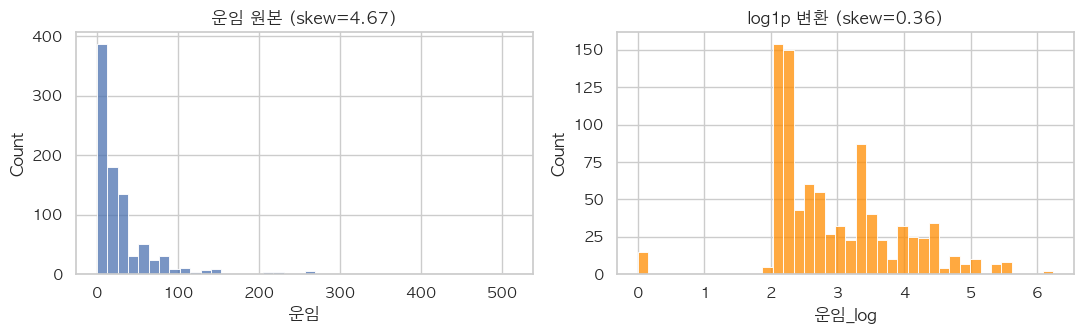

In [30]:
titanic["운임_log"] = np.log1p(titanic["운임"])

fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))
sns.histplot(titanic["운임"], bins=40, ax=axes[0])
axes[0].set_title(f"운임 원본 (skew={titanic['운임'].skew():.2f})")
sns.histplot(titanic["운임_log"], bins=40, ax=axes[1], color="darkorange")
axes[1].set_title(f"log1p 변환 (skew={titanic['운임_log'].skew():.2f})")
plt.tight_layout()
plt.show()

titanic = titanic.drop(columns=["운임"])

---
## 7. 구간화: 나이구간, 가족규모

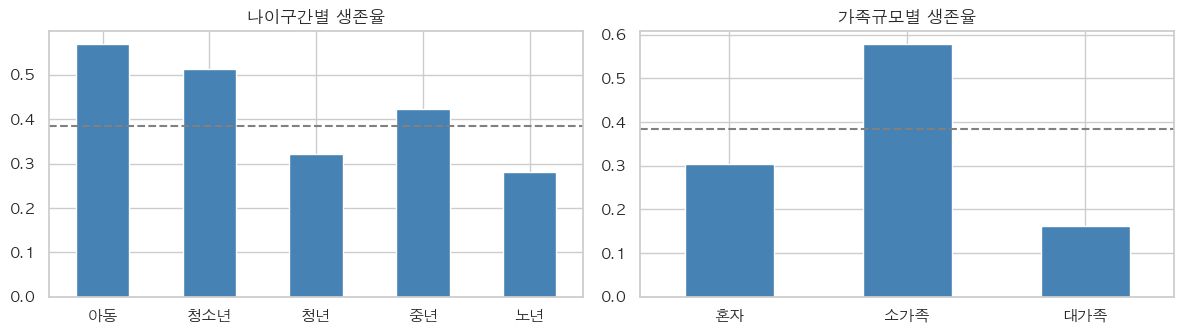

{'아동': 72, '청소년': 78, '청년': 480, '중년': 236, '노년': 25}
{'혼자': 537, '소가족': 292, '대가족': 62}


In [31]:
titanic["나이구간"] = pd.cut(titanic["나이"], bins=[0, 12, 18, 35, 60, 100],
                         labels=["아동", "청소년", "청년", "중년", "노년"], right=False)
titanic["가족수"] = titanic["동반형제배우자"] + titanic["동반부모자녀"] + 1
titanic["가족규모"] = pd.cut(titanic["가족수"], bins=[0, 1, 4, 20], labels=["혼자", "소가족", "대가족"])

fig, axes = plt.subplots(1, 2, figsize=(12, 3.5))
for ax, col in zip(axes, ["나이구간", "가족규모"]):
  rate = titanic.groupby(col, observed=True)["생존"].mean()
  rate.plot(kind="bar", ax=ax, rot=0, color="steelblue")
  ax.axhline(titanic["생존"].mean(), color="gray", linestyle="--")
  ax.set_title(f"{col}별 생존율")
  ax.set_xlabel("")
plt.tight_layout()
plt.show()

print(titanic["나이구간"].value_counts().sort_index().to_dict())
print(titanic["가족규모"].value_counts().sort_index().to_dict())

- `right=False` 이므로 `[0, 12)` 가 아동: **12세는 청소년** 입니다.
- `가족규모` 는 `(0, 1]` 혼자, `(1, 4]` 소가족, `(4, 20]` 대가족입니다 (`right=True` 기본).
- 소가족의 생존율이 혼자·대가족보다 높은 **비선형 패턴** 이 범주로 바뀌어 잘 드러납니다.

---
## 8. 인코딩

| 컬럼 | 종류 | 방법 |
|------|------|------|
| 성별 | 이진 | `map({"male": 0, "female": 1})` |
| 객실등급 | 순서형 (이미 1/2/3) | 그대로 |
| 탑승항구, 호칭, 나이구간, 가족규모 | 명목형 (나이구간은 순서가 있지만 생존과 비선형이라 원-핫) | `get_dummies(drop_first=True, dtype=int)` |

In [32]:
titanic["성별"] = titanic["성별"].map({"male": 0, "female": 1})
titanic = pd.get_dummies(titanic, columns=["탑승항구", "호칭", "나이구간", "가족규모"], drop_first=True, dtype=int)

print("문자열·범주 컬럼 남음:", titanic.select_dtypes(include=["object", "category"]).columns.tolist())
print("결측:", titanic.isnull().sum().sum(), "| shape:", titanic.shape)
print(titanic.columns.tolist())

문자열·범주 컬럼 남음: []
결측: 0 | shape: (891, 22)
['생존', '객실등급', '성별', '나이', '동반형제배우자', '동반부모자녀', '나이결측', '객실정보유무', '운임_log', '가족수', '탑승항구_Q', '탑승항구_S', '호칭_Miss', '호칭_Mr', '호칭_Mrs', '호칭_기타', '나이구간_청소년', '나이구간_청년', '나이구간_중년', '나이구간_노년', '가족규모_소가족', '가족규모_대가족']


---
## 9. 분할과 스케일링

In [33]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X = titanic.drop(columns=["생존"])
y = titanic["생존"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print("train:", X_train.shape, "생존율", round(y_train.mean(), 3), "| test:", X_test.shape, "생존율", round(y_test.mean(), 3))

train: (712, 21) 생존율 0.383 | test: (179, 21) 생존율 0.385


In [34]:
# 0/1 컬럼(이진·원-핫)은 그대로 두고, 크기가 있는 수치형만 표준화
SCALE_COLS = ["객실등급", "나이", "동반형제배우자", "동반부모자녀", "운임_log", "가족수"]
scaler = StandardScaler()
X_train_s = X_train.copy()
X_test_s = X_test.copy()
X_train_s[SCALE_COLS] = scaler.fit_transform(X_train[SCALE_COLS])
X_test_s[SCALE_COLS] = scaler.transform(X_test[SCALE_COLS])
X_train_s[SCALE_COLS].describe().loc[["mean", "std"]].round(2)

,객실등급,나이,동반형제배우자,동반부모자녀,운임_log,가족수
mean,-0.0,-0.0,-0.0,-0.0,0.0,0.0
std,1.0,1.0,1.0,1.0,1.0,1.0


---
## 10. 전처리 효과 확인: 최소 처리 vs 전체 전처리

같은 `LogisticRegression` 으로 비교합니다. 두 방식 모두 **같은 승객으로 분할** 하고, 평가도 같은 test 승객으로 합니다.

- **(A) 최소 처리**: 문자열 컬럼 삭제, 성별 map, 결측 있는 행은 **삭제**
- **(B) 전체 전처리**: 이 노트북의 결과

In [35]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score

train_idx, test_idx = X_train.index, X_test.index

# (A) 결측이 추가된 데이터를 최소 처리
raw, _ = make_missing(titanic_true, MISSING_RATIOS, seed=42)
raw = raw.drop(columns=["승객ID", "이름", "티켓번호", "객실번호", "탑승항구"])
raw["성별"] = raw["성별"].map({"male": 0, "female": 1})
raw_train = raw.loc[train_idx].dropna()
raw_test = raw.loc[test_idx].dropna()                 # 결측 있는 test 승객은 예측조차 못 한다
clf_a = LogisticRegression(max_iter=1000).fit(raw_train.drop(columns=["생존"]), raw_train["생존"])
pred_a = clf_a.predict(raw_test.drop(columns=["생존"]))

# (B) 전체 전처리
clf_b = LogisticRegression(max_iter=1000).fit(X_train_s, y_train)
pred_b = clf_b.predict(X_test_s)

pd.DataFrame([
  {"방식": "(A) 최소 처리", "학습 승객": len(raw_train), "예측 가능한 test 승객": f"{len(raw_test)} / {len(test_idx)}",
   "정확도": round(accuracy_score(raw_test["생존"], pred_a), 4), "F1": round(f1_score(raw_test["생존"], pred_a), 4)},
  {"방식": "(B) 전체 전처리", "학습 승객": len(X_train_s), "예측 가능한 test 승객": f"{len(X_test_s)} / {len(test_idx)}",
   "정확도": round(accuracy_score(y_test, pred_b), 4), "F1": round(f1_score(y_test, pred_b), 4)},
]).set_index("방식")

,학습 승객,예측 가능한 test 승객,정확도,F1
방식,,,,
(A) 최소 처리,499,120 / 179,0.7833,0.7292
(B) 전체 전처리,712,179 / 179,0.8324,0.7826


**가장 큰 차이는 "예측 가능한 승객 수"** 입니다. 결측 행을 지우는 방식은 학습 데이터가 줄어들 뿐 아니라, **결측이 있는 새 승객은 아예 예측할 수 없습니다.** 실제 서비스에서는 치명적입니다. 정확도 숫자는 (A) 가 예측한 승객만으로 계산되었으므로, 두 방식의 정확도를 그대로 비교할 때는 이 점을 감안해야 합니다.

---
## 11. 저장

In [36]:
X_train_s.assign(생존=y_train.values).to_csv(f"{DATA_DIR}/titanic_preprocessed_train.csv", index=False)
X_test_s.assign(생존=y_test.values).to_csv(f"{DATA_DIR}/titanic_preprocessed_test.csv", index=False)
print("저장 완료:", X_train_s.shape, X_test_s.shape)

저장 완료: (712, 21) (179, 21)


#### 이 예제의 전처리 결정 요약

| 단계 | 결정 | 근거 (EDA / 채점) |
|------|------|------|
| 파생 | 이름 → 호칭 (드문 호칭은 기타) | 호칭별 나이·성별·생존율 차이 |
| 결측 (수치) | 나이: 객실등급+호칭 → 호칭 → 전체 중앙값 단계 대체, 운임: 객실등급별 중앙값 | 4장 MAE 비교 |
| 결측 (범주) | 성별: 호칭 규칙 → 최빈값, 탑승항구: 최빈값 | 4장 정확도 비교 |
| 결측 = 정보 | 객실정보유무, 나이결측 표시 | 객실 기록 여부별 생존율 차이 |
| 삭제 | 승객ID, 이름, 티켓번호, 객실번호 | 고유값 과다 / 77% 결측 |
| 이상치 | 운임 삭제하지 않고 log1p | 극단값 승객의 생존율이 높음 |
| 구간화 | 나이구간, 가족규모 | 생존과 비선형 관계 |
| 인코딩 | 성별 map, 명목형 원-핫(drop_first) | 이진 / 순서 없음 |
| 분할·스케일링 | 생존 층화 8:2, 수치형만 StandardScaler | 38:62 비율 유지, 단위 차이 |

---
## 12. 실습 문제

원본 파일을 다시 읽고, 나이와 탑승항구에 결측을 추가로 만든 데이터로 시작합니다.

In [37]:
df = pd.read_csv(f"{DATA_DIR}/titanic_train.csv").rename(columns=TITANIC_COLS)
df, _ = make_missing(df, {"나이": 0.05, "탑승항구": 0.05}, seed=7)
print(df.isnull().sum()[lambda s: s > 0])

나이      221
객실번호    687
탑승항구     46
dtype: int64


### 문제 1. 호칭 추출

`이름` 에서 호칭을 뽑아 `호칭` 컬럼을 만드시오. `Mlle`, `Ms` 는 `Miss` 로, `Mme` 는 `Mrs` 로 바꾸고, `Mr`, `Mrs`, `Miss`, `Master` 가 아닌 호칭은 모두 `"기타"` 로 바꾼 뒤 값별 개수를 출력하시오.

In [38]:
# 여기에 코드를 작성하세요

<details>
<summary>정답 보기</summary>

```python
df["호칭"] = df["이름"].str.extract(r",\s*([^\.]+)\.", expand=False).str.strip()
df["호칭"] = df["호칭"].replace({"Mlle": "Miss", "Ms": "Miss", "Mme": "Mrs"})
df["호칭"] = df["호칭"].where(df["호칭"].isin(["Mr", "Mrs", "Miss", "Master"]), "기타")
print(df["호칭"].value_counts())
```

</details>

### 문제 2. 그룹별 결측 대체

`나이` 결측을 **`객실등급`·`성별` 조합별 중앙값** 으로 채우시오. 채운 뒤 `나이` 의 결측 개수와, `객실등급`·`성별` 조합별 나이 중앙값 표를 출력하시오.

In [39]:
# 여기에 코드를 작성하세요

<details>
<summary>정답 보기</summary>

```python
df["나이"] = df["나이"].fillna(df.groupby(["객실등급", "성별"])["나이"].transform("median"))
print(df["나이"].isna().sum())
print(df.groupby(["객실등급", "성별"])["나이"].median().unstack())
```

</details>

### 문제 3. 범주형 결측과 결측 표시 변수

1. `객실번호` 가 있으면 1, 없으면 0 인 `객실정보유무` 컬럼을 만들고 `객실번호` 를 삭제하시오.
2. `탑승항구` 결측을 최빈값으로 채우시오.
3. `객실정보유무` 별 생존율을 출력하시오.

In [40]:
# 여기에 코드를 작성하세요

<details>
<summary>정답 보기</summary>

```python
df["객실정보유무"] = df["객실번호"].notna().astype(int)
df = df.drop(columns=["객실번호"])
df["탑승항구"] = df["탑승항구"].fillna(df["탑승항구"].mode()[0])
print(df.groupby("객실정보유무")["생존"].mean().round(3))
```

</details>

### 문제 4. 인코딩부터 스케일링까지

문제 1~3 의 결과에서 다음을 수행하시오.
1. `승객ID`, `이름`, `티켓번호` 삭제
2. `운임` 을 `log1p` 변환 (컬럼명 그대로)
3. `성별` 을 male=0, female=1 로, `탑승항구`·`호칭` 을 원-핫 인코딩 (`drop_first=True`, 정수형)
4. `생존` 을 y 로 하여 7:3 층화 분할 (`random_state=0`), 변수명 `X_train, X_test, y_train, y_test`
5. `나이`, `운임` 만 `StandardScaler` 로 변환

`X_train` 의 shape 과 `X_train[["나이", "운임"]]` 의 평균·표준편차를 출력하시오.

In [41]:
# 여기에 코드를 작성하세요

<details>
<summary>정답 보기</summary>

```python
df = df.drop(columns=["승객ID", "이름", "티켓번호"])
df["운임"] = np.log1p(df["운임"])
df["성별"] = df["성별"].map({"male": 0, "female": 1})
df = pd.get_dummies(df, columns=["탑승항구", "호칭"], drop_first=True, dtype=int)

X = df.drop(columns=["생존"])
y = df["생존"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=0, stratify=y)

sc = StandardScaler()
X_train[["나이", "운임"]] = sc.fit_transform(X_train[["나이", "운임"]])
X_test[["나이", "운임"]] = sc.transform(X_test[["나이", "운임"]])
print(X_train.shape)
print(X_train[["나이", "운임"]].agg(["mean", "std"]).round(2))
```

</details>